## **Figure-S4**

In [1]:
import pandas as pd
import polars as pl
from functools import reduce
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import sys
import numpy as np
import matplotlib as mpl

from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker


sys.path.append("../../scripts")

from figure_utils import *

---

---

In [2]:
names = dict(exp='Experimental',
             silico='in-silico',
             bruker='timsTOF, 2024',
             panhuman='PanHuman, 2014',
             diatracer='Direct')

condition = dict(orig='Initial', refined='GPF-based')

## **Load Data**

#### **OSW - Identification Rates**

In [3]:
osw = { n:defaultdict(dict) for n in names.values() }

# Diatracer data
osw[names['diatracer']][condition['orig']]['1'] = getProteinSet("../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['diatracer']][condition['orig']]['2'] = getProteinSet("../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['diatracer']][condition['orig']]['3'] = getProteinSet("../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw[names['diatracer']][condition['refined']]['1'] = getProteinSet("../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['diatracer']][condition['refined']]['2'] = getProteinSet("../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['diatracer']][condition['refined']]['3'] = getProteinSet("../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

# Bruker data
osw[names['bruker']][condition['orig']]['1'] = getProteinSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['bruker']][condition['orig']]['2'] = getProteinSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['bruker']][condition['orig']]['3'] = getProteinSet("../../results/K562-Bruker-Library-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw[names['bruker']][condition['refined']]['1'] = getProteinSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['bruker']][condition['refined']]['2'] = getProteinSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['bruker']][condition['refined']]['3'] = getProteinSet("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

# Panhuman data - Use SVM because XGBoost overfits 
osw[names['panhuman']][condition['orig']]['1'] = getProteinSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/")
osw[names['panhuman']][condition['orig']]['2'] = getProteinSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/")
osw[names['panhuman']][condition['orig']]['3'] = getProteinSet_oswpq("../../results/K562-PanHuman-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/")

osw[names['panhuman']][condition['refined']]['1'] = getProteinSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq/")
osw[names['panhuman']][condition['refined']]['2'] = getProteinSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq/")
osw[names['panhuman']][condition['refined']]['3'] = getProteinSet_oswpq("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_SVM/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq/")

# Experimental data
osw[names['exp']][condition['orig']]['1'] = getProteinSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['exp']][condition['orig']]['2'] = getProteinSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['exp']][condition['orig']]['3'] = getProteinSet("../../results/K562-Exp-Lib-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

osw[names['exp']][condition['refined']]['1'] = getProteinSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['exp']][condition['refined']]['2'] = getProteinSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['exp']][condition['refined']]['3'] = getProteinSet("../../results/K562-Exp-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

# Silico data
osw[names['silico']][condition['orig']]['1'] = getProteinSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.oswpq")
osw[names['silico']][condition['orig']]['2'] = getProteinSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.oswpq")
osw[names['silico']][condition['orig']]['3'] = getProteinSet_oswpq("../../results/K562-PeptDeep-NoMods-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.oswpq")

osw[names['silico']][condition['refined']]['1'] = getProteinSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet")
osw[names['silico']][condition['refined']]['2'] = getProteinSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet")
osw[names['silico']][condition['refined']]['3'] = getProteinSet("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet")

../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet
../../results/K562-diaTracer/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021.parquet
../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021.parquet
../../results/K562-GPF-diaTracer-OSW-Analysis/osw/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/pyprophet_XGB/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021.parquet
../../results/K562-GP

#### **DIA-NN Identification Rates**

In [4]:
diann = { n:defaultdict(dict) for n in names.values() }


# Bruker data
diann[names['bruker']][condition['orig']]['1'] = getProteinSetDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['bruker']][condition['orig']]['2'] = getProteinSetDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['bruker']][condition['orig']]['3'] = getProteinSetDiann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['bruker']][condition['refined']]['1'] = getProteinSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['bruker']][condition['refined']]['2'] = getProteinSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['bruker']][condition['refined']]['3'] = getProteinSetDiann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

# Silico data
diann[names['silico']][condition['orig']]['1'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['silico']][condition['orig']]['2'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['silico']][condition['orig']]['3'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['silico']][condition['refined']]['1'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['silico']][condition['refined']]['2'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['silico']][condition['refined']]['3'] = getProteinSetDiann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

# Diatracer data
diann[names['diatracer']][condition['orig']]['1'] = getProteinSetDiann("../../results/K562-diaTracer/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['diatracer']][condition['orig']]['2'] = getProteinSetDiann("../../results/K562-diaTracer/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['diatracer']][condition['orig']]['3'] = getProteinSetDiann("../../results/K562-diaTracer/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['diatracer']][condition['refined']]['1'] = getProteinSetDiann("../../results/K562-GPF-diaTracer-DIANN-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['diatracer']][condition['refined']]['2'] = getProteinSetDiann("../../results/K562-GPF-diaTracer-DIANN-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['diatracer']][condition['refined']]['3'] = getProteinSetDiann("../../results/K562-GPF-diaTracer-DIANN-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

# exp data
diann[names['exp']][condition['orig']]['1'] = getProteinSetDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['exp']][condition['orig']]['2'] = getProteinSetDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['exp']][condition['orig']]['3'] = getProteinSetDiann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['exp']][condition['refined']]['1'] = getProteinSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['refined']]['2'] = getProteinSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['refined']]['3'] = getProteinSetDiann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv", infer_schema_length=1000)

# Panhuman data
diann[names['panhuman']][condition['orig']]['1'] = getProteinSetDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['panhuman']][condition['orig']]['2'] = getProteinSetDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['panhuman']][condition['orig']]['3'] = getProteinSetDiann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

diann[names['panhuman']][condition['refined']]['1'] = getProteinSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['panhuman']][condition['refined']]['2'] = getProteinSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv")
diann[names['panhuman']][condition['refined']]['3'] = getProteinSetDiann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv")

../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv
../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_2_Slot1-5_1_1331_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_3_Slot1-5_1_1332_6-28-2021/report.tsv
../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_10

In [5]:
osw_ids = format_ids_vs_reproducibility(osw)
diann_ids = format_ids_vs_reproducibility(diann)

In [6]:
osw_ids

,Condition,Library,# IDs,Jaccard Index
0,Initial,Experimental,7202.666667,0.959199
1,GPF-based,Experimental,7534.000000,0.977602
2,Initial,in-silico,7813.666667,0.845050
3,GPF-based,in-silico,8329.333333,0.953869
4,Initial,"timsTOF, 2024",7817.666667,0.915313
5,GPF-based,"timsTOF, 2024",8645.333333,0.978865
6,Initial,"PanHuman, 2014",6069.666667,0.928002
7,GPF-based,"PanHuman, 2014",6692.000000,0.976082
8,Initial,Direct,6693.000000,0.901419
9,GPF-based,Direct,6993.333333,0.976170


In [7]:
diann_ids

,Condition,Library,# IDs,Jaccard Index
0,Initial,Experimental,7444.000000,0.967408
1,GPF-based,Experimental,7472.666667,0.977332
2,Initial,in-silico,7671.333333,0.937785
3,GPF-based,in-silico,7938.666667,0.970382
4,Initial,"timsTOF, 2024",8173.666667,0.931928
5,GPF-based,"timsTOF, 2024",8140.666667,0.966978
6,Initial,"PanHuman, 2014",6529.666667,0.942294
7,GPF-based,"PanHuman, 2014",6634.666667,0.964275
8,Initial,Direct,6678.333333,0.906008
9,GPF-based,Direct,7085.666667,0.983577


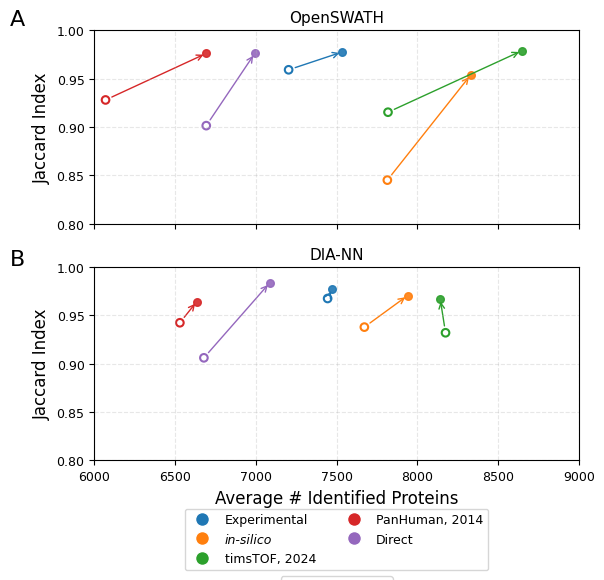

In [8]:
def createID_Reproducibility_plot(df, 
                                  title, 
                                  ax, 
                                  show_legends=True, 
                                  panel_label='', 
                                  show_xlabel=True,
                                  show_ylabel=True,
                                  font_size_small = 9,
                                  font_size_medium = 12,
                                  font_size_large = 14,
                                  font_size_title = 11):
    # Set style
    plt.style.use('default')
    sns.set_palette("husl")
    
    library_colors = {
        names['exp']: '#1f77b4',
        names['silico']: '#ff7f0e', 
        names['bruker']: '#2ca02c',
        names['panhuman']: '#d62728',
        names['diatracer']: '#9467bd'
    }
    
    point_size=30
    edge_width=1.5
    
    for library in df['Library'].unique():
        lib_data = df[df['Library'] == library]
        original = lib_data[lib_data['Condition'] == condition['orig']]
        refined = lib_data[lib_data['Condition'] == condition['refined']]
        color = library_colors[library]
        
        short_name = library.replace(' Library', '')
        ax.scatter(original['# IDs'], original['Jaccard Index'], 
                     s=point_size, facecolors='none', edgecolors=color, linewidth=edge_width, label=short_name)
        ax.scatter(refined['# IDs'], refined['Jaccard Index'],
                     s=point_size, c=color, alpha=0.9)
                     
        arrow = FancyArrowPatch(
            (original['# IDs'].iloc[0], original['Jaccard Index'].iloc[0]),
            (refined['# IDs'].iloc[0], refined['Jaccard Index'].iloc[0]),
            arrowstyle='->', mutation_scale=10, shrinkA=5, shrinkB=2,
            color=color, alpha=1, linewidth=1
        )
        ax.add_patch(arrow)
        
    if show_xlabel:
        ax.set_xlabel('Average # Identified Proteins', fontsize=font_size_medium)
    else:
        ax.set_xlabel('')
        
    if show_ylabel:
        ax.set_ylabel('Jaccard Index', fontsize=font_size_medium)
    
    x_min, x_max = df['# IDs'].min() - 2000, df['# IDs'].max() + 2000
    y_min, y_max = df['Jaccard Index'].min() - 0.01, df['Jaccard Index'].max() + 0.01
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    ax.tick_params(axis='both', which='major', labelsize=font_size_small)
    ax.tick_params(axis='y', which='major', labelsize=font_size_small)
    
    ax.grid(True, alpha=0.3, linestyle='--')
    
    if panel_label:
        ax.text(0, 1.02, panel_label, transform=ax.transAxes, fontsize=font_size_large, 
                         fontweight='bold', verticalalignment='bottom', horizontalalignment='left')

    if show_legends:
        condition_legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
                   markeredgecolor='black', markersize=7, markeredgewidth=1.5, 
                   label=condition['orig'], linestyle='None'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
                   markersize=10, alpha=1, label=condition['refined'], linestyle='None'),
        ]
        library_legend_elements = []
        for library, color in library_colors.items():
            short_name = library.replace(' Library', '')
            library_legend_elements.append(
                Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                       markersize=10, alpha=1, label=short_name, 
                       linestyle='None')
            )
        legend1 = ax.legend(handles=condition_legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.85), 
                     fontsize=font_size_small)
        leg = ax.legend(handles=library_legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.6), 
                     fontsize=font_size_small)
        leg.get_texts()[1].set_style('italic')
        ax.add_artist(legend1)

    
    ax.set_xlim(6000, 9000)
    ax.set_ylim(0.8, 1.0)
    ax.set_title(title, fontsize=font_size_title)

# We keep the 7x7 figure size
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

createID_Reproducibility_plot(osw_ids, title='OpenSWATH', ax=ax1, show_legends=False, panel_label='', show_xlabel=False, show_ylabel=True)
createID_Reproducibility_plot(diann_ids, title='DIA-NN', ax=ax2, show_legends=True, panel_label='', show_xlabel=True)

fig.text(0, 0.95, 'A', fontsize=16) 
fig.text(0, 0.55, 'B', fontsize=16) 
plt.tight_layout()
plt.savefig("Figure-S4.png", dpi=300, bbox_inches='tight')